In [1]:
import pandas as pd
import glob
import os
import warnings

warnings.filterwarnings("ignore")

In [2]:


# Define folder path
folder_path = "/Users/dougs/Annapurna Dropbox/Doug Sack/Interactive/IndieBI/sales_curve_data/units/"

# Get all .xlsx files in the folder
files = glob.glob(f"{folder_path}/*.xlsx")

# Read all files into DataFrames and add filename column
dfs = [pd.read_excel(file, skiprows=2).assign(Source=os.path.basename(file)) for file in files]




In [3]:
df = pd.concat(dfs, ignore_index=True)


In [4]:
df.head()

,Date,product,Cumulative Selected Measure,Source
0,2018-12-07,Ashen,2290,epic_units.xlsx
1,2018-12-08,Ashen,4713,epic_units.xlsx
2,2018-12-09,Ashen,7038,epic_units.xlsx
3,2018-12-10,Ashen,8702,epic_units.xlsx
4,2018-12-11,Ashen,10125,epic_units.xlsx


In [5]:
df.Source.unique()

array(['epic_units.xlsx', 'nintendo_units.xlsx', 'steam_units.xlsx',
       'PS_units.xlsx'], dtype=object)

In [6]:
file_name = 'epic_units'

In [7]:
release_dict = {'The Lost Wild': '2025-12-31',
 'Wattam': '2019-12-17',
 'Storyteller: Devilish Update': '2023-09-26',
 'The Artful Escape': '2021-09-09',
 'Annapurna Interactive Deluxe Limited Edition Collection': '2023-12-22',
 'Annapurna Interactive: Ultimate Collection': '2020-12-08',
 'Annapurna Interactive Deluxe Limited Edition': '2020-12-15',
 'I Am Dead': '2020-10-08',
 'Outer Wilds: Archaeologist Edition': '2021-09-28',
 'The Pathless': '2020-11-12',
 'If Found...': '2020-05-19',
 'Telling Lies': '2019-08-23',
 'A Memoir Blue': '2022-03-24',
 'Stray': '2022-07-19',
 'Last Stop': '2021-07-22',
 'To a T': '2025-05-28',
 'Mundaun': '2021-03-16',
 'Solar Ash': '2021-12-02',
 'What Remains of Edith Finch': '2017-04-24',
 'Sayonara Wild Hearts': '2019-9-19',
 'Lushfoil Photography Sim': '2025-04-15',
 'Storyteller': '2023-03-23',
 'Gorogoa': '2017-12-13',
 'Wanderstop': '2025-03-11',
 'Journey': '2012-03-13',
 'Mixtape': '2025-12-31',
 'Open Roads': '2024-03-28',
 'Neon White': '2022-06-16',
 'Flower': '2009-02-12',
 'Twelve Minutes': '2021-08-19',
 'Outer Wilds: Echoes of the Eye': '2021-09-28',
 'Flock': '2024-07-16',
 'Maquette': '2021-03-02',
 'Cocoon': '2023-09-29',
 'Gone Home': '2013-08-15',
 'Outer Wilds': '2019-05-28',
 'Ashen: Nightstorm Isle': '2019-09-06',
 'Florence': '2018-02-13',
 'Thirsty Suitors': '2023-11-02',
 'Lorelei and the Laser Eyes': '2024-05-16',
 'Donut County': '2018-08-28',
 'Skin Deep': '2025-04-30',
 'Wheel World': '2025-06-30',
 'Hohokum': '2014-08-12',
 'Ashen: Definitive Edition': '2019-11-18',
 'Morsels': '2025-12-31',
 'Kentucky Route Zero: TV Edition': '2020-01-28',
 'The Unfinished Swan': '2012-10-23',
 'Hindsight': '2022-08-04',
 'Ashen': '2018-12-07'}

In [8]:
df_combined = df.query(f"Source =='{file_name}.xlsx'")
#df_combined['release_date'] = df_combined['product'].map(release_dict)

In [9]:
df_combined

,Date,product,Cumulative Selected Measure,Source
0,2018-12-07,Ashen,2290,epic_units.xlsx
1,2018-12-08,Ashen,4713,epic_units.xlsx
2,2018-12-09,Ashen,7038,epic_units.xlsx
3,2018-12-10,Ashen,8702,epic_units.xlsx
4,2018-12-11,Ashen,10125,epic_units.xlsx
...,...,...,...,...
28780,2025-03-17,Solar Ash,16321,epic_units.xlsx
28781,2025-03-17,The Pathless,19398,epic_units.xlsx
28782,2025-03-17,The Unfinished Swan,4756,epic_units.xlsx
28783,2025-03-17,Wattam,10265,epic_units.xlsx


In [10]:
df_combined['release_date'] = pd.to_datetime(df_combined['Date'])

In [11]:
df_combined['release_date'] = df_combined.groupby('product')['release_date'].transform('min')

In [12]:
df_combined["DAR"] = (df_combined["Date"] - df_combined["release_date"]).dt.days
#df_combined["DAR"] = df_combined["DAR"].clip(lower=0)

df_combined["Weeks_from_Release"] = (df_combined["DAR"] // 7) + 1  # Week 1 starts at 0-7 days

df_combined = df_combined.query("0 <= Weeks_from_Release <=52")

df_combined = df_combined.query("'1/1/2015' <= release_date <='1/1/2025'")

df_combined = df_combined.groupby(["product", "Weeks_from_Release"], as_index=False)["Cumulative Selected Measure"].max()

In [13]:
title_exclusion = [
'Stray','Outer Wilds'
    

]

In [14]:
df_combined['product'].unique()

array(['Ashen', 'Ashen - Nightstorm Isle DLC', 'Donut County', 'Flower',
       'Gorogoa', 'I Am Dead', 'Journey', 'Mundaun', 'Outer Wilds',
       'Outer Wilds - Archaeologist Edition BUNDLE',
       'Outer Wilds - Echoes of the Eye DLC', 'Solar Ash', 'The Pathless',
       'The Unfinished Swan', 'Wattam', 'What Remains of Edith Finch'],
      dtype=object)

In [15]:
df_combined

,product,Weeks_from_Release,Cumulative Selected Measure
0,Ashen,1,12463
1,Ashen,2,19942
2,Ashen,3,24855
3,Ashen,4,28011
4,Ashen,5,29929
...,...,...,...
827,What Remains of Edith Finch,48,2285
828,What Remains of Edith Finch,49,2314
829,What Remains of Edith Finch,50,2341
830,What Remains of Edith Finch,51,2353


In [16]:
df_combined = df_combined.query("product !=@title_exclusion")

In [17]:
#pd.set_option("display.max_rows", None)


df_combined["CUME_total"] = df_combined.groupby(["product"])["Cumulative Selected Measure"].transform("max")
df_combined["prop_of_total"] = df_combined["Cumulative Selected Measure"] / df_combined["CUME_total"]
df_combined["daily_delta"] = df_combined.groupby(["product"])["Cumulative Selected Measure"].pct_change().fillna(0)
df_combined.query("product=='Maquette'")


,product,Weeks_from_Release,Cumulative Selected Measure,CUME_total,prop_of_total,daily_delta


In [18]:
df_combined.query("Weeks_from_Release==1")


,product,Weeks_from_Release,Cumulative Selected Measure,CUME_total,prop_of_total,daily_delta
0,Ashen,1,12463,71541,0.174208,0.0
52,Ashen - Nightstorm Isle DLC,1,435,2086,0.208533,0.0
104,Donut County,1,139,2043,0.068037,0.0
156,Flower,1,435,4088,0.106409,0.0
208,Gorogoa,1,44,831,0.052948,0.0
260,I Am Dead,1,318,1595,0.199373,0.0
312,Journey,1,20581,85264,0.241380,0.0
364,Mundaun,1,1,480,0.002083,0.0
468,Outer Wilds - Archaeologist Edition BUNDLE,1,234,8723,0.026826,0.0
520,Outer Wilds - Echoes of the Eye DLC,1,10715,22151,0.483725,0.0


In [19]:
platform_df = df_combined.groupby("Weeks_from_Release")[['daily_delta']].mean()
platform_df['platform'] = 'epic'

In [20]:
platform_df

,daily_delta,platform
Weeks_from_Release,,
1,0.000000,epic
2,0.706986,epic
3,1.164324,epic
4,0.251864,epic
5,0.142566,epic
6,0.492901,epic
7,0.096379,epic
8,0.066268,epic
9,0.064807,epic


In [21]:
platform_df.to_csv(f"units/{file_name}_average.csv")

In [22]:
stop

NameError: name 'stop' is not defined

In [24]:
### Fit the Curve to a model and use this to predict



# Define folder path
folder_path = "/Users/dougs/Documents/GitHub/IndieBI-Sales-EDA/units/"

# Get all .xlsx files in the folder
files = glob.glob(f"{folder_path}/*.csv")

# Read all files into DataFrames and add filename column
dfs = [pd.read_csv(file).assign(Source=os.path.basename(file)) for file in files]




In [25]:
files

['/Users/dougs/Documents/GitHub/IndieBI-Sales-EDA/units/epic_units_average.csv',
 '/Users/dougs/Documents/GitHub/IndieBI-Sales-EDA/units/PS_units_average.csv',
 '/Users/dougs/Documents/GitHub/IndieBI-Sales-EDA/units/nintendo_units_average.csv',
 '/Users/dougs/Documents/GitHub/IndieBI-Sales-EDA/units/steam_units_average.csv']

In [26]:
av_df = pd.concat(dfs, ignore_index=True)


In [27]:
platforms = av_df.pivot_table(columns='platform', index='Weeks_from_Release', values='daily_delta').reset_index()

In [28]:
platforms.to_clipboard()

In [29]:
platforms.columns[1:]

Index(['PS', 'epic', 'nintendo', 'steam'], dtype='object', name='platform')

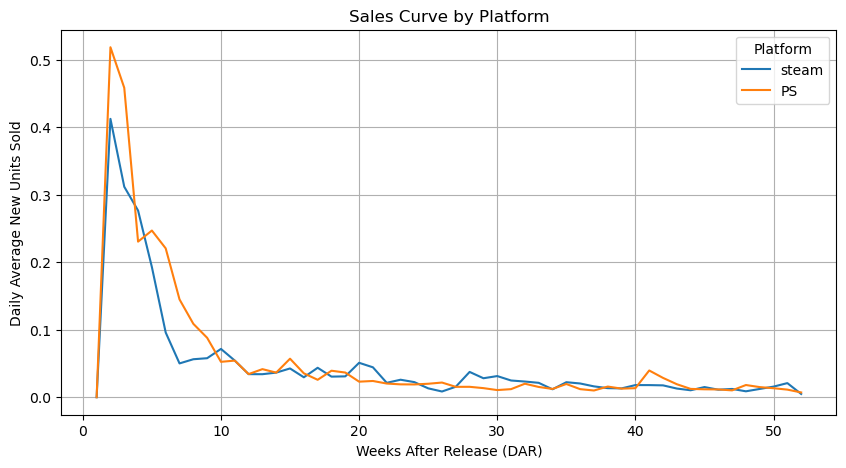

In [30]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))  # Adjust figure size for better visibility

# Loop through unique platforms and plot each separately
for platform in ['steam', 'PS']:
    pdf = av_df.query("platform == @platform")
    sns.lineplot(data=pdf, x='Weeks_from_Release', y='daily_delta', label=platform)

# Improve aesthetics
plt.xlabel("Weeks After Release (DAR)")
plt.ylabel("Daily Average New Units Sold")
plt.title("Sales Curve by Platform")
plt.legend(title="Platform", loc="best")  # Set legend title
plt.grid(True)  # Add grid for readability

plt.show()

In [31]:
platforms.query("Weeks_from_Release <=12")

platform,Weeks_from_Release,PS,epic,nintendo,steam
0,1,0.000000,0.000000,0.000000,0.000000
1,2,0.518450,0.706986,1.101720,0.412323
2,3,0.458287,1.164324,0.299089,0.311766
3,4,0.230487,0.251864,0.132276,0.276515
4,5,0.246892,0.142566,0.086132,0.192767
5,6,0.220479,0.492901,0.072239,0.095831
6,7,0.144904,0.096379,0.042954,0.050078
7,8,0.108725,0.066268,0.062439,0.056263
8,9,0.088022,0.064807,0.062956,0.057790
9,10,0.052433,0.035943,0.056466,0.071555


In [32]:
starting_val = 31_200

In [33]:
current_week  = 1

In [34]:
platforms.loc[current_week-1,'steam_projected'] = starting_val

In [35]:
platforms.loc[current_week-1,'steam_projected'] = starting_val

In [36]:
# Apply cumulative product starting from the specified index
platforms.loc[current_week:, 'steam_projected'] = (
    starting_val * (1 + platforms.loc[current_week:, 'steam']).cumprod()
)

In [37]:
platforms['steam_projected'] = platforms['steam_projected'].fillna(starting_val)
platforms['steam_projected'] = platforms['steam_projected'].astype(int)

In [38]:
platforms.to_clipboard()
platforms

platform,Weeks_from_Release,PS,epic,nintendo,steam,steam_projected
0,1,0.000000,0.000000,0.000000,0.000000,31200
1,2,0.518450,0.706986,1.101720,0.412323,44064
2,3,0.458287,1.164324,0.299089,0.311766,57802
3,4,0.230487,0.251864,0.132276,0.276515,73785
4,5,0.246892,0.142566,0.086132,0.192767,88008
5,6,0.220479,0.492901,0.072239,0.095831,96442
6,7,0.144904,0.096379,0.042954,0.050078,101272
7,8,0.108725,0.066268,0.062439,0.056263,106970
8,9,0.088022,0.064807,0.062956,0.057790,113152
9,10,0.052433,0.035943,0.056466,0.071555,121248


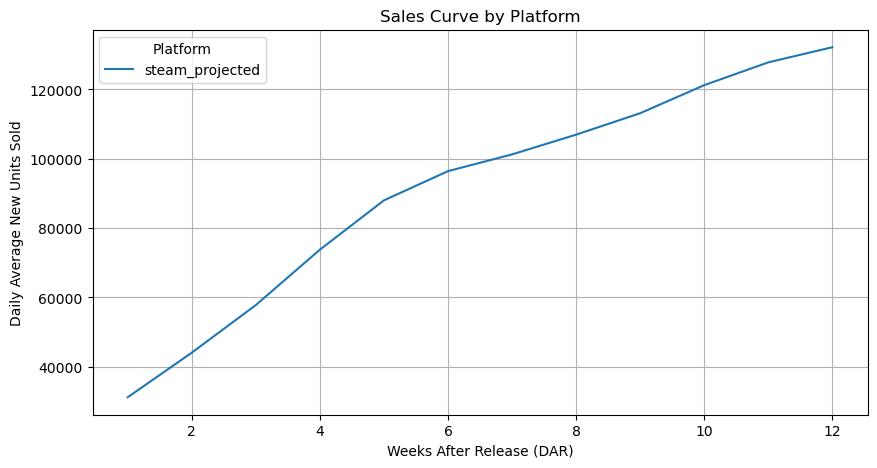

In [39]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))  # Adjust figure size for better visibility


sns.lineplot(data=platforms.query("Weeks_from_Release <=12"), x='Weeks_from_Release', y='steam_projected', label='steam_projected')

# Improve aesthetics
plt.xlabel("Weeks After Release (DAR)")
plt.ylabel("Daily Average New Units Sold")
plt.title("Sales Curve by Platform")
plt.legend(title="Platform", loc="best")  # Set legend title
plt.grid(True)  # Add grid for readability

plt.show()